# Data Driven Models: Linear Regression Modelling Examples

### Last Class
- Linear regression diagnostics

### Goals for Today
- Construct linear regression models using the modelling process

In [2]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy.stats import poisson
from scipy.stats import norm
%matplotlib inline

print("packages imported")

packages imported


### Example - Galapogos plants
The `galapogos.csv` data describe the relationship between the number of plant species and several geographic variables on $30$ Galapagos islands.  Using area, elevation, nearest, scruz, and adjacent as the inputs, constuct a mathematical model of the species. 

**Problem Statements:**

1. Model the relationship between the number of plant species and the 30 geographic variables.

2. Construct a linear regression that represents the relationship between the number of plant species and the geography of 30 Galapogos Islands 


**Variables & Parameters - No dimensions given in prompt**
- Y is number of species
- $X_i$ are the columns
- $B_i$ are each beta column

**Assumptions**
- Errors are independent and identically distributed
- Errors are normally distributed with mean 0 and constant variance
- The model follows a linear model $Y=B_0 + B_1X_1 +B_2X_2 + \dots$

We are assuming the errors things but we still have to check them




In [3]:
data = pd.read_csv("DATA/galapogos.csv")
data.head()

,Unnamed: 0,Species,Endemics,Area,Elevation,Nearest,Scruz,Adjacent
0,Baltra,58,23,25.09,346,0.6,0.6,1.84
1,Bartolome,31,21,1.24,109,0.6,26.3,572.33
2,Caldwell,3,3,0.21,114,2.8,58.7,0.78
3,Champion,25,9,0.10,46,1.9,47.4,0.18
4,Coamano,2,1,0.05,77,1.9,1.9,903.82


In [4]:
## THIS IS THE MODEL 

Y = data['Species']
X = data[['Area', 'Elevation', 'Nearest', 'Scruz', 'Adjacent']]

X = sm.add_constant(X)
model = sm.OLS(Y,X).fit()
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     15.70
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           6.84e-07
Time:                        18:32:40   Log-Likelihood:                -162.54
No. Observations:                  30   AIC:                             337.1
Df Residuals:                      24   BIC:                             345.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0682     19.154      0.369      0.7

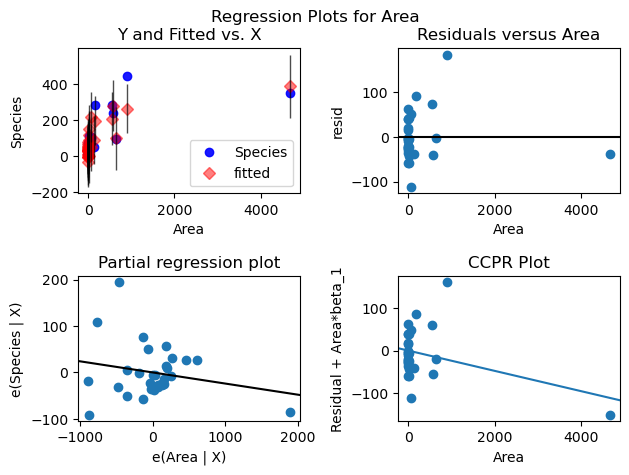

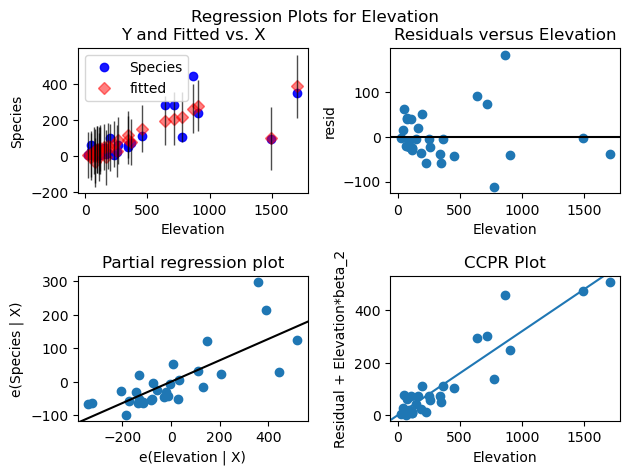

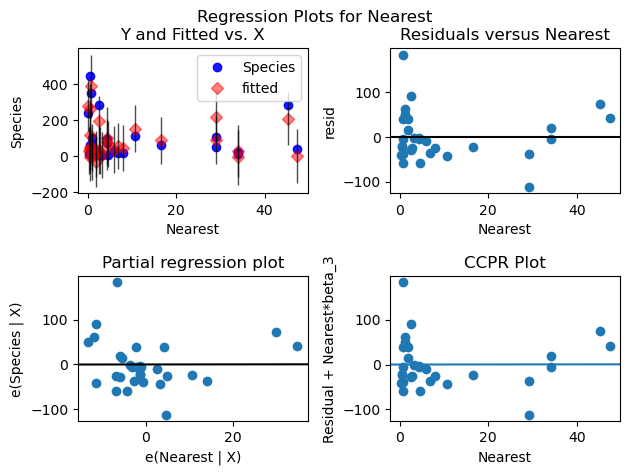

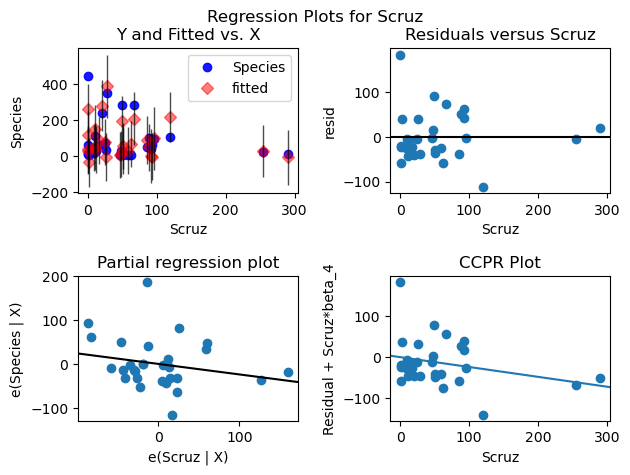

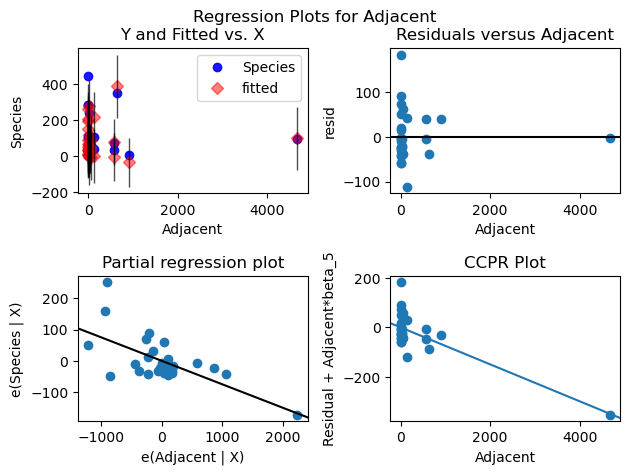

In [5]:
sm.graphics.plot_regress_exog(model, 'Area')
plt.show()

sm.graphics.plot_regress_exog(model, 'Elevation')
plt.show()

sm.graphics.plot_regress_exog(model, 'Nearest')
plt.show()

sm.graphics.plot_regress_exog(model, 'Scruz')
plt.show()

sm.graphics.plot_regress_exog(model, 'Adjacent')
plt.show()

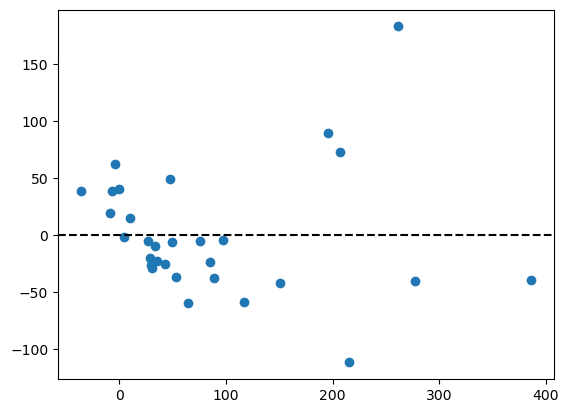

In [6]:
fitted_y = model.fittedvalues
residuals = model.resid

plt.scatter(fitted_y, residuals)
plt.axhline(y=0, c='k', linestyle='--')
plt.show()

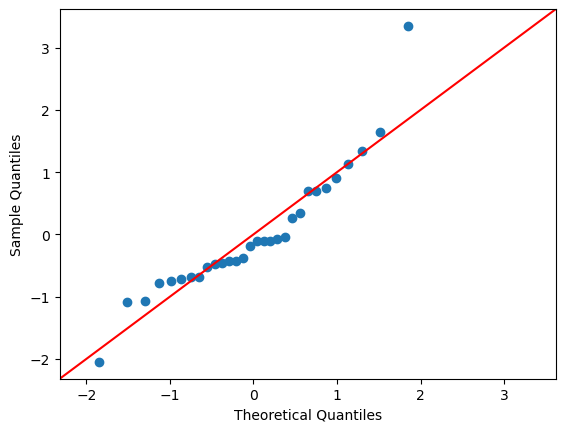

In [7]:
sm.qqplot(residuals, fit=True, line="45")
plt.show()

### Example - Insurance 

Insurance companies know that car speed has an effect on the stopping distance and they would like to have a model to predict a vehicle's stopping distance for a given speed.

They have a dataset called `speed.csv` that has $62$ observations under similar conditions. The speed is measured in km/h and the distance is measured in m.  Construct a mathematical model of the stopping distance.  

**Problem Statement:**

Create a linear regression model that measures the stopping distance (m) based on the speed (km/hr) of a car. 

**Assumptions:**
- The model will follow a linear regression of the form: $Y = \beta_0 + \beta_1x + \epsilon$
- The errors $\epsilon_i$ have mean of zero
- The errors $\epsilon_i$ have constant variance of $\sigma^2$
- The errors $\epsilon_i$ follow a normal distribution
- The data collected is accurate and is a good predictor for the future
- Driver skill can be ignored, i.e. the stopping power from the driver on the pedal is the same for any different driver
- The kind of car is ignored, i.e. this data is true for any car.

**Variables**
- $\hat{\beta_0}$ the intercept
- $\hat{\beta_1}$ the slope 
- $\hat{Y}$ the estimated expected stopping distance
- $Y$ is the true stopping distance
- $X$ the speed of the vehicle
- $\epsilon$ the error of the line

In [8]:
data = pd.read_csv('DATA/speed.csv')
data.head()

,Speed,Distance
0,4,4
1,5,2
2,5,4
3,5,8
4,5,8


In [12]:
Y = data['Distance']
X = data['Speed']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
summary = model.summary()

print(summary)

                            OLS Regression Results                            
Dep. Variable:               Distance   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     430.6
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           4.58e-29
Time:                        18:50:00   Log-Likelihood:                -239.82
No. Observations:                  62   AIC:                             483.6
Df Residuals:                      60   BIC:                             487.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -20.1309      3.231     -6.231      0.0

Adjusted R^squared looks good we now should do some diagnostics on the errors

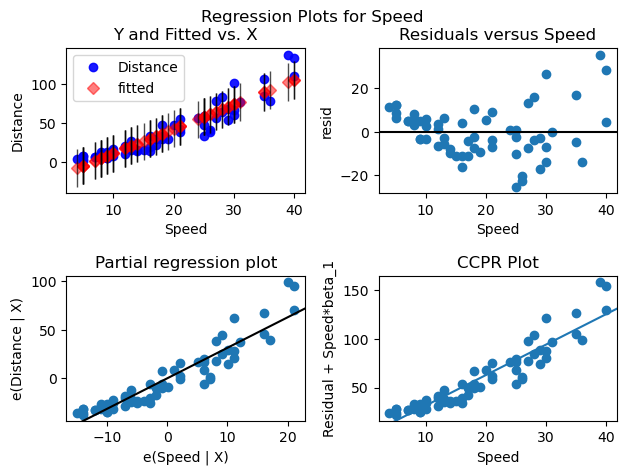

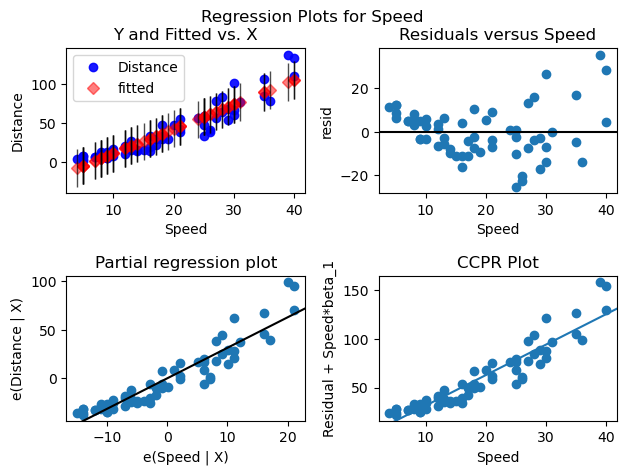

In [13]:
sm.graphics.plot_regress_exog(model, 'Speed')

very bad curved shape to the residual vs covariate plot, implies that the variance of the errors are not constant and that the average value is not zero.

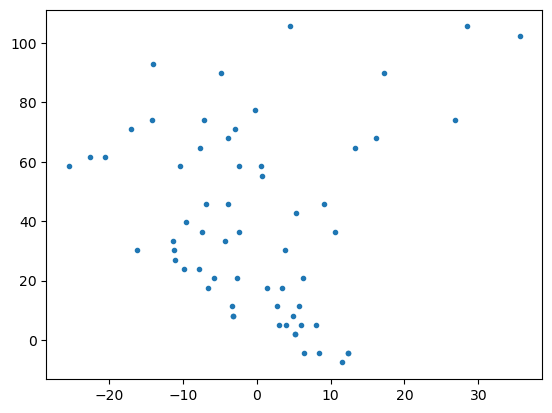

In [18]:
res = model.resid
fit = model.fittedvalues
plt.plot(res, fit, ".")

cloud doesnt look too bad but the variance of the errors is definitely not constant

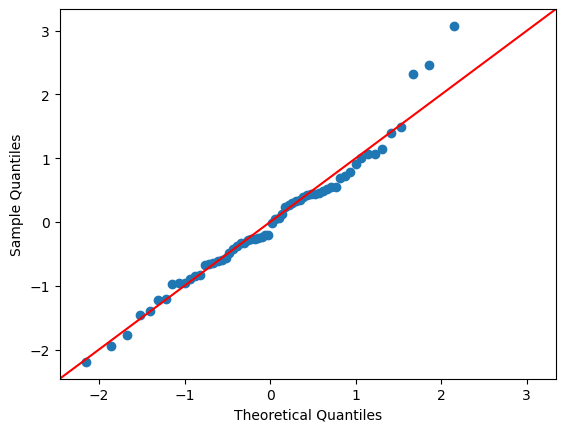

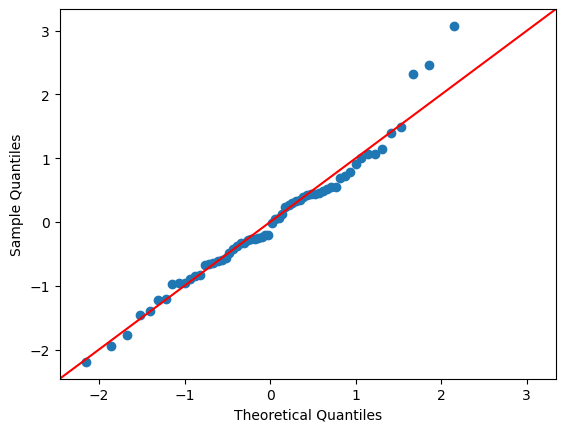

In [22]:
sm.qqplot(res, fit=True, line='45')

these look pretty good so the errors are probably normal. Diagonistically it seems the average value of the residuals is not zero and the variance of the residuals is not constant.